# Sistemas Inteligentes I
## Búsqueda no informada: BFS y DFS

**Autor:** Jairo I. Vélez B.  
**Desarrollado y resuelto por:** Juan David Ocampo González

---

### Propósito de la práctica

En este notebook estudiaremos cómo resolver problemas mediante **búsqueda no informada**, es decir, estrategias que exploran el espacio de estados **sin disponer de una estimación sobre qué tan cerca se encuentra cada estado del objetivo**.

Al finalizar la práctica, el estudiante estará en capacidad de:

- Representar un problema mediante un **espacio de estados**.
- Implementar **Búsqueda en Anchura (BFS)**.
- Implementar **Búsqueda en Profundidad (DFS)**.
- Comparar el comportamiento de BFS y DFS.
- Aplicar estos algoritmos a problemas concretos.
- Analizar ventajas, limitaciones y costo de exploración.


## 1. Idea general: buscar sin información adicional

Un problema de búsqueda puede describirse mediante:

- **Estado inicial:** punto desde el cual comienza la búsqueda.
- **Estados:** configuraciones posibles del problema.
- **Acciones u operadores:** transformaciones permitidas entre estados.
- **Función sucesor:** determina qué estados pueden alcanzarse desde un estado dado.
- **Prueba de objetivo:** determina si se alcanzó la solución.

En la búsqueda no informada, el algoritmo **no conoce qué estado parece más prometedor**.  
Solo utiliza la estructura del espacio de búsqueda.

Dos estrategias fundamentales son:

- **BFS (Breadth-First Search):** explora por niveles.
- **DFS (Depth-First Search):** profundiza por una rama antes de retroceder.


## 2. Librerías utilizadas

Se utilizarán únicamente estructuras básicas de Python y matplotlib para algunas visualizaciones.


In [1]:
from collections import deque
import matplotlib.pyplot as plt

print("Entorno listo.")


Entorno listo.


# 3. Primer espacio de estados: un grafo

Consideremos el siguiente grafo no ponderado:

- **Estado:** un nodo.
- **Estado inicial:** `A`.
- **Acciones:** desplazarse hacia un nodo adyacente.
- **Objetivo inicial de la demostración:** observar el orden de exploración.

La representación mediante un diccionario de listas de adyacencia es:


In [2]:
grafo = {
    "A": ["B", "F"],
    "B": ["A", "C", "E"],
    "C": ["B", "D", "E"],
    "D": ["C", "E", "F"],
    "E": ["B", "C", "D"],
    "F": ["A", "D"],
}

grafo


{'A': ['B', 'F'],
 'B': ['A', 'C', 'E'],
 'C': ['B', 'D', 'E'],
 'D': ['C', 'E', 'F'],
 'E': ['B', 'C', 'D'],
 'F': ['A', 'D']}

## 4. Búsqueda en Anchura — BFS

BFS utiliza una **cola FIFO** (*First In, First Out*).

La idea es simple:

1. Insertar el estado inicial en la cola.
2. Extraer el primer estado de la cola.
3. Encontrar sus sucesores no visitados.
4. Insertarlos al final de la cola.
5. Repetir hasta terminar o encontrar el objetivo.

En grafos no ponderados, BFS puede encontrar un camino con el **menor número de aristas** desde el origen hasta el objetivo.


In [3]:
def bfs(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    recorrido = []

    while cola:
        nodo = cola.popleft()
        recorrido.append(nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

    return recorrido


recorrido_bfs = bfs(grafo, "A")
print("Recorrido BFS:", recorrido_bfs)


Recorrido BFS: ['A', 'B', 'F', 'C', 'E', 'D']


### 4.1 BFS paso a paso

Para comprender el algoritmo conviene observar cómo cambian la **frontera** y el conjunto de **visitados**.


In [4]:
def bfs_debug(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    paso = 1

    while cola:
        print(f"\nPaso {paso}")
        print("Cola antes de expandir:", list(cola))
        print("Visitados:", sorted(visitados))

        nodo = cola.popleft()
        print("Nodo expandido:", nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

        print("Cola después de expandir:", list(cola))
        paso += 1


bfs_debug(grafo, "A")



Paso 1
Cola antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Cola después de expandir: ['B', 'F']

Paso 2
Cola antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: B
Cola después de expandir: ['F', 'C', 'E']

Paso 3
Cola antes de expandir: ['F', 'C', 'E']
Visitados: ['A', 'B', 'C', 'E', 'F']
Nodo expandido: F
Cola después de expandir: ['C', 'E', 'D']

Paso 4
Cola antes de expandir: ['C', 'E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Cola después de expandir: ['E', 'D']

Paso 5
Cola antes de expandir: ['E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Cola después de expandir: ['D']

Paso 6
Cola antes de expandir: ['D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: D
Cola después de expandir: []


# 5. Búsqueda en Profundidad — DFS

DFS utiliza una **pila LIFO** (*Last In, First Out*).

Su comportamiento es diferente:

1. Inserta el estado inicial en la pila.
2. Extrae el estado ubicado en la parte superior.
3. Agrega sus sucesores no visitados.
4. Continúa profundizando por una rama.
5. Cuando no puede avanzar, retrocede implícitamente mediante la pila.

> El orden en el que se generan los sucesores puede cambiar el recorrido obtenido.


In [5]:
def dfs(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    recorrido = []

    while pila:
        nodo = pila.pop()
        recorrido.append(nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

    return recorrido


recorrido_dfs = dfs(grafo, "A")
print("Recorrido DFS:", recorrido_dfs)


Recorrido DFS: ['A', 'F', 'D', 'E', 'C', 'B']


### 5.1 DFS paso a paso


In [6]:
def dfs_debug(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    paso = 1

    while pila:
        print(f"\nPaso {paso}")
        print("Pila antes de expandir:", pila)
        print("Visitados:", sorted(visitados))

        nodo = pila.pop()
        print("Nodo expandido:", nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

        print("Pila después de expandir:", pila)
        paso += 1


dfs_debug(grafo, "A")



Paso 1
Pila antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Pila después de expandir: ['B', 'F']

Paso 2
Pila antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: F
Pila después de expandir: ['B', 'D']

Paso 3
Pila antes de expandir: ['B', 'D']
Visitados: ['A', 'B', 'D', 'F']
Nodo expandido: D
Pila después de expandir: ['B', 'C', 'E']

Paso 4
Pila antes de expandir: ['B', 'C', 'E']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Pila después de expandir: ['B', 'C']

Paso 5
Pila antes de expandir: ['B', 'C']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Pila después de expandir: ['B']

Paso 6
Pila antes de expandir: ['B']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: B
Pila después de expandir: []


## 6. BFS vs. DFS

| Característica | BFS | DFS |
|---|---|---|
| Estructura principal | Cola | Pila |
| Estrategia | Explora por niveles | Profundiza por ramas |
| Camino mínimo en grafo no ponderado | Sí | No necesariamente |
| Uso de memoria | Puede ser alto | Suele ser menor |
| Riesgo principal | Explosión de memoria | Profundizar demasiado |
| ¿Usa heurística? | No | No |

### Pregunta para discutir

**¿Existe un único recorrido BFS o DFS para un grafo?**

No necesariamente. El resultado puede cambiar según el orden en que se generen o almacenen los sucesores.


# 7. Problema 1: encontrar la salida de un laberinto

Usaremos `0` para representar una celda transitable y `1` para representar una pared.

Modelado:

- **Estado:** `(fila, columna)`.
- **Estado inicial:** `(0, 0)`.
- **Objetivo:** `(4, 4)`.
- **Acciones:** arriba, abajo, izquierda y derecha.
- **Restricción:** no atravesar paredes ni salir del tablero.


In [7]:
laberinto = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
]

INICIO = (0, 0)
OBJETIVO = (4, 4)
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)]


In [8]:
def sucesores_laberinto(laberinto, posicion):
    filas = len(laberinto)
    columnas = len(laberinto[0])
    f, c = posicion

    sucesores = []

    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc

        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores


## 7.1 Resolver el laberinto con BFS

Además del camino, contabilizaremos cuántos estados fueron descubiertos.


In [9]:
def bfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    cola = deque([(inicio, [inicio])])
    visitados = {inicio}

    while cola:
        posicion, camino = cola.popleft()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in sucesores_laberinto(laberinto, posicion):
            if nuevo not in visitados:
                visitados.add(nuevo)
                cola.append((nuevo, camino + [nuevo]))

    return None


resultado_bfs = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_bfs


{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 16}

## 7.2 Resolver el mismo laberinto con DFS


In [10]:
def dfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    pila = [(inicio, [inicio])]
    visitados = {inicio}

    while pila:
        posicion, camino = pila.pop()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in (sucesores_laberinto(laberinto, posicion)):
            if nuevo not in visitados:
                visitados.add(nuevo)
                pila.append((nuevo, camino + [nuevo]))

    return None


resultado_dfs = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_dfs


{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 18}

## 7.3 Visualización del camino

La visualización permite comparar no solo si ambos algoritmos encuentran una solución, sino **qué tipo de camino producen**.


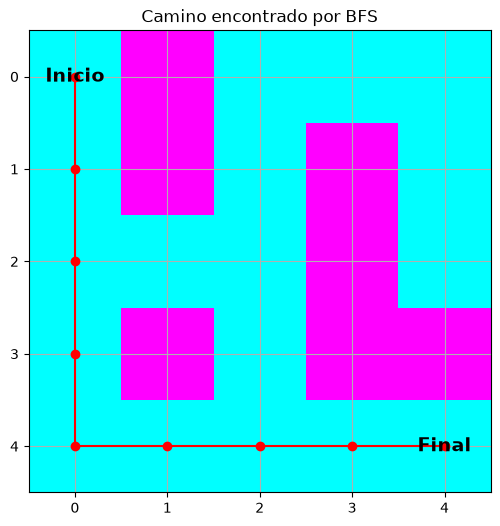

In [11]:
def mostrar_laberinto(laberinto, camino=None, inicio=None, objetivo=None, titulo="Laberinto"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(laberinto, cmap='cool')

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c='red', marker="o")

    if inicio is not None:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=14, color="black", weight="bold")
    if objetivo is not None:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=14, color="black", weight="bold")

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    plt.show()


mostrar_laberinto(
    laberinto,
    resultado_bfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por BFS"
)


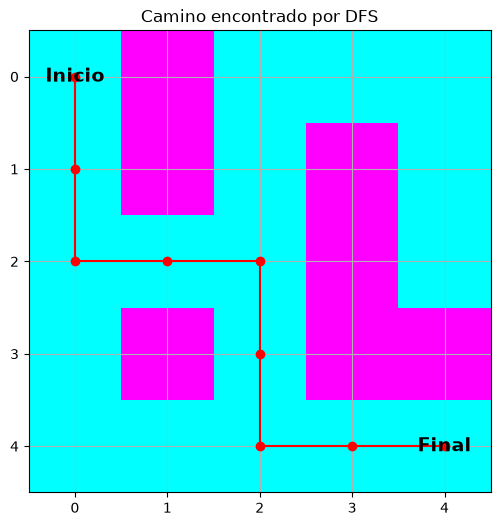

In [12]:
mostrar_laberinto(
    laberinto,
    resultado_dfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por DFS"
)


## 7.4 Comparación experimental


In [13]:
comparacion = {
    "BFS": {
        "longitud_camino": len(resultado_bfs["camino"]) - 1,
        "explorados": resultado_bfs["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs["camino"]) - 1,
        "explorados": resultado_dfs["explorados"],
    },
}

comparacion


{'BFS': {'longitud_camino': 8, 'explorados': 16},
 'DFS': {'longitud_camino': 8, 'explorados': 18}}

### Respuestas a las Preguntas de análisis (Sección 7.4)

1. **¿Ambos algoritmos encontraron una solución?**  
   **Sí.** Tanto BFS como DFS hallaron un camino continuo y válido a través de casillas transitables (`0`) que conecta la casilla inicial `(0, 0)` con el objetivo `(4, 4)`.

2. **¿Los caminos tienen la misma longitud?**  
   **Sí, en este laberinto en particular.** Ambos caminos tienen una longitud de **8 pasos** (compuestos por 9 estados cada uno). Sin embargo, las trayectorias físicas son diferentes: BFS desciende directamente por la primera columna hasta el borde inferior `(4, 0)` y bordea hacia la derecha `(4, 4)`, mientras que DFS dobla prematuramente hacia la derecha en la fila 2 atravesando el centro del laberinto. Que tengan la misma longitud es una particularidad de la topología de este laberinto y del orden de operadores; en el caso general, DFS no garantiza encontrar el camino más corto.

3. **¿Cuál exploró más estados?**  
   **DFS exploró más estados (18 estados)** en comparación con **BFS (16 estados)**. DFS profundizó en bifurcaciones y ramas sin salida antes de retroceder, lo que incrementó el número total de nodos ingresados a la estructura de visitados.

4. **¿Por qué BFS puede garantizar el camino con menor número de movimientos en este problema?**  
   Porque en este laberinto no ponderado, cada movimiento de una casilla adyacente a otra tiene exactamente el mismo costo unitario ($c = 1$). Al usar una cola FIFO, BFS expande los nodos rigurosamente por niveles de profundidad crecientes ($d = 0, 1, 2, \dots$). En consecuencia, el primer momento en que el estado objetivo `(4, 4)` es alcanzado, se tiene la certeza matemática de que no existe ningún otro camino con un número menor de aristas.

5. **¿Cambiaría el resultado de DFS si modificamos el orden de `MOVIMIENTOS`?**  
   **Sí, de manera sustancial.** DFS utiliza una pila LIFO, lo que significa que el último sucesor agregado a la pila será el primero en ser explorado a fondo. Cambiar el orden de la lista de operadores altera qué rama se recorre primero, cambiando radicalmente la ruta encontrada y la cantidad de nodos explorados antes de llegar a la meta.


# 8. Problema 2: recipientes de agua

Se dispone de:

- Un recipiente **M** con capacidad de 5 litros.
- Un recipiente **N** con capacidad de 3 litros.
- Una fuente ilimitada de agua.
- El objetivo es obtener **exactamente 4 litros**.

## Representación del estado

Un estado será una tupla:

\[
(m,n)
\]

donde:

- `m` = cantidad de agua en el recipiente M.
- `n` = cantidad de agua en el recipiente N.

Estado inicial:

\[
(0,0)
\]

### Operadores

1. Llenar M.
2. Llenar N.
3. Vaciar M.
4. Vaciar N.
5. Verter N → M.
6. Verter M → N.


In [14]:
def sucesores_recipientes(estado, M, N):
    m, n = estado

    return [
        ((M, n), "Llenar M"),
        ((m, N), "Llenar N"),
        ((0, n), "Vaciar M"),
        ((m, 0), "Vaciar N"),

        # Verter N -> M
        (
            (
                min(M, m + n),
                max(0, m + n - M)
            ),
            "Verter N → M"
        ),

        # Verter M -> N
        (
            (
                max(0, m + n - N),
                min(N, m + n)
            ),
            "Verter M → N"
        ),
    ]


In [15]:
def bfs_recipientes(M, N, objetivo):
    inicio = (0, 0)
    cola = deque([(inicio, [inicio], [])])
    visitados = {inicio}

    while cola:
        estado, camino, acciones = cola.popleft()

        if objetivo in estado:
            return {
                "estados": camino,
                "acciones": acciones,
                "explorados": len(visitados),
            }

        for nuevo_estado, accion in sucesores_recipientes(estado, M, N):
            if nuevo_estado not in visitados:
                visitados.add(nuevo_estado)
                cola.append(
                    (
                        nuevo_estado,
                        camino + [nuevo_estado],
                        acciones + [accion],
                    )
                )

    return None


solucion_recipientes = bfs_recipientes(5, 3, 4)
solucion_recipientes


{'estados': [(0, 0), (5, 0), (2, 3), (2, 0), (0, 2), (5, 2), (4, 3)],
 'acciones': ['Llenar M',
  'Verter M → N',
  'Vaciar N',
  'Verter M → N',
  'Llenar M',
  'Verter M → N'],
 'explorados': 14}

## 8.1 Mostrar la solución paso a paso


In [16]:
def mostrar_solucion_recipientes(solucion):
    if solucion is None:
        print("No se encontró solución.")
        return

    estados = solucion["estados"]
    acciones = solucion["acciones"]

    print("Estado inicial:", estados[0])

    for i, accion in enumerate(acciones, start=1):
        print(f"{i}. {accion:15s} -> {estados[i]}")

    print("\nEstados explorados:", solucion["explorados"])


mostrar_solucion_recipientes(solucion_recipientes)


Estado inicial: (0, 0)
1. Llenar M        -> (5, 0)
2. Verter M → N    -> (2, 3)
3. Vaciar N        -> (2, 0)
4. Verter M → N    -> (0, 2)
5. Llenar M        -> (5, 2)
6. Verter M → N    -> (4, 3)

Estados explorados: 14


### Respuestas a las Preguntas de análisis (Sección 8.1)

1. **¿Por qué el problema de los recipientes puede representarse como un grafo?**  
   Porque cada configuración discreta de volumen de agua en los dos recipientes $(m, n)$ constituye un nodo (estado) bien definido dentro de un espacio finito, y cada una de las 6 operaciones admisibles (llenar, vaciar o transferir agua) representa una arista dirigida y determinista que conecta un estado origen con un estado destino.

2. **¿Cuántos estados posibles existen como máximo?**  
   El recipiente $M$ puede contener valores enteros desde $0$ hasta $M$ ($M+1$ valores posibles), y el recipiente $N$ desde $0$ hasta $N$ ($N+1$ valores posibles). Por regla del producto, el espacio de estados teórico máximo es de:
   $$\text{Total de estados teóricos} = (M + 1) \times (N + 1)$$
   Para el caso $M = 5$ y $N = 3$, el espacio total es de $(5 + 1) \times (3 + 1) = 6 \times 4 = 24$ estados. Solo un subconjunto de estos 24 estados resulta alcanzable desde el estado inicial `(0, 0)`.

3. **¿Qué representa una arista entre dos estados?**  
   Una arista representa la aplicación de un operador o acción física válida permitida por las reglas del problema (por ejemplo, *Llenar M*, *Vaciar N*, o *Verter M → N*) que transforma el estado actual $(m, n)$ en un nuevo estado $(m', n')$.

4. **¿Por qué BFS es una estrategia apropiada si queremos minimizar el número de operaciones?**  
   Dado que cada operación de trasvase, llenado o vaciado tiene un costo equivalente (costo de paso unitario $c = 1$), minimizar el costo equivale a minimizar la cantidad de pasos de la secuencia. BFS explora exhaustivamente por niveles concéntricos de profundidad, garantizando encontrar la secuencia de acciones con la menor cantidad de pasos posible.

5. **¿Qué cambiaría si cada operación tuviera un costo distinto?**  
   Si las operaciones tuvieran costos diferentes (por ejemplo, si verter agua costara 1 unidad pero llenar un recipiente desde el grifo costara 5 unidades de agua o energía), BFS **ya no garantizaría la solución óptima**. En tal escenario, se debería utilizar el algoritmo de **Búsqueda de Costo Uniforme (UCS / Dijkstra)**, que expande nodos priorizando el menor costo acumulado $g(n)$ mediante una cola de prioridad.


# 9. Reto final: el 8-puzzle

El 8-puzzle consiste en un tablero de `3 × 3` con ocho fichas y una casilla vacía.

Cada configuración del tablero representa un **estado**.

El objetivo es transformar un estado inicial en un estado objetivo moviendo una ficha adyacente hacia la posición vacía.

Este problema será especialmente útil más adelante, cuando comparemos **búsqueda no informada** con **búsqueda informada y A\***.


In [17]:
estado_inicial = (
    1, 2, 3,
    4, 5, 0,
    6, 8, 7,
)

estado_objetivo = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0,
)

estado_inicial, estado_objetivo


((1, 2, 3, 4, 5, 0, 6, 8, 7), (1, 2, 3, 4, 5, 6, 7, 8, 0))

## 9.1 Generación de sucesores

El `0` representa la casilla vacía.

La siguiente función genera todos los estados alcanzables mediante **un movimiento válido**.


In [18]:
def sucesores_8_puzzle(estado):
    estado = list(estado)
    indice_cero = estado.index(0)

    fila, columna = divmod(indice_cero, 3)

    movimientos = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
    ]

    sucesores = []

    for df, dc in movimientos:
        nf, nc = fila + df, columna + dc

        if 0 <= nf < 3 and 0 <= nc < 3:
            nuevo_indice = nf * 3 + nc
            nuevo = estado.copy()

            nuevo[indice_cero], nuevo[nuevo_indice] = (
                nuevo[nuevo_indice],
                nuevo[indice_cero],
            )

            sucesores.append(tuple(nuevo))

    return sucesores


sucesores_8_puzzle(estado_inicial)


[(1, 2, 0, 4, 5, 3, 6, 8, 7),
 (1, 2, 3, 4, 5, 7, 6, 8, 0),
 (1, 2, 3, 4, 0, 5, 6, 8, 7)]

## 9.2 Ejercicio resuelto: Implementación de BFS para el 8-puzzle

Implementamos a continuación la función `bfs_8_puzzle(estado_inicial, estado_objetivo)` solicitada, cumpliendo con:
- Uso estricto de BFS (cola FIFO).
- Control de estados visitados (conjunto hash para evitar ciclos y repeticiones).
- Cero heurísticas.
- Retorno de: camino completo, número de movimientos y cantidad de estados explorados.


In [19]:
def bfs_8_puzzle(estado_inicial, estado_objetivo):
    if estado_inicial == estado_objetivo:
        return {
            "camino": [estado_inicial],
            "movimientos": 0,
            "explorados": 1,
        }

    cola = deque([(estado_inicial, [estado_inicial])])
    visitados = {estado_inicial}

    while cola:
        estado_actual, camino = cola.popleft()

        if estado_actual == estado_objetivo:
            return {
                "camino": camino,
                "movimientos": len(camino) - 1,
                "explorados": len(visitados),
            }

        for sucesor in sucesores_8_puzzle(estado_actual):
            if sucesor not in visitados:
                visitados.add(sucesor)
                cola.append((sucesor, camino + [sucesor]))

    return None

# Estado soluble a 2 movimientos del objetivo para la demostracion:
estado_demo_8p = (
    1, 2, 3,
    4, 0, 5,
    7, 8, 6,
)
solucion_8p = bfs_8_puzzle(estado_demo_8p, estado_objetivo)
print("Movimientos necesarios:", solucion_8p["movimientos"])
print("Estados explorados:", solucion_8p["explorados"])
print("Longitud del camino:", len(solucion_8p["camino"]))


Movimientos necesarios: 2
Estados explorados: 20
Longitud del camino: 3


### Visualización del camino paso a paso en el 8-puzzle


In [20]:
def imprimir_tablero(estado):
    for i in range(0, 9, 3):
        fila = [str(x) if x != 0 else " " for x in estado[i:i+3]]
        print(" | ".join(fila))
    print("-" * 9)

print("Secuencia de solución encontrada por BFS:")
for paso_num, est in enumerate(solucion_8p["camino"]):
    print(f"Paso {paso_num}:")
    imprimir_tablero(est)


Secuencia de solución encontrada por BFS:
Paso 0:
1 | 2 | 3
4 |   | 5
7 | 8 | 6
---------
Paso 1:
1 | 2 | 3
4 | 5 |  
7 | 8 | 6
---------
Paso 2:
1 | 2 | 3
4 | 5 | 6
7 | 8 |  
---------


### Respuesta a la pregunta (Sección 9.2)

> **Pregunta:** ¿Qué problema aparece cuando el estado inicial se encuentra muy lejos del objetivo?

**Respuesta:**  
Aparece el fenómeno de la **explosión combinatoria del espacio de estados y consumo exponencial de memoria**.  
En el 8-puzzle, el factor de ramificación efectivo promedio es $b \approx 2.67$. Si una solución óptima se encuentra a una profundidad de $d = 20$ o más movimientos (el diámetro máximo del 8-puzzle es de 31 movimientos):
- BFS almacena todos los nodos de la frontera en la cola en memoria RAM, requiriendo un orden de complejidad espacial $O(b^d)$.
- A profundidad $d = 20$, la cola tendría que almacenar del orden de $2.67^{20} \approx 2.8 \times 10^8$ estados, saturando la memoria del computador antes de poder alcanzar el objetivo.
- Por tanto, la búsqueda no informada se vuelve computacionalmente inviable para problemas complejos o distancias moderadas/largas, haciendo indispensable la **búsqueda informada (heurísticas como A*)**.


# 10. Conclusiones

En esta práctica observamos que:

- Un problema puede modelarse mediante **estados, acciones y una condición objetivo**.
- BFS y DFS son estrategias de búsqueda **no informada**.
- BFS explora por niveles y utiliza una cola.
- DFS profundiza por ramas y utiliza una pila.
- BFS puede encontrar caminos mínimos cuando todas las acciones tienen el mismo costo.
- DFS puede requerir menos memoria, pero no garantiza un camino mínimo.
- El tamaño del espacio de estados puede hacer que una búsqueda no informada sea muy costosa.

---

## Pregunta

Si el espacio de búsqueda contiene millones de estados:

> **¿Podríamos utilizar información del problema para decidir qué estados parecen más prometedores y explorarlos primero?**

Esa pregunta nos lleva a la **búsqueda informada y las heurísticas**.


# 11. Taller para estudiar — Desarrollo y Experimentación Completa

---

### Punto 1: Modificación del orden de los movimientos del laberinto y comparación con DFS

Evaluamos tres órdenes distintos de operadores en la lista `MOVIMIENTOS` sobre el laberinto de la Sección 7 para analizar el impacto en DFS:
- **Orden 1 (Original):** Abajo `(1,0)`, Arriba `(-1,0)`, Derecha `(0,1)`, Izquierda `(0,-1)`
- **Orden 2 (Invertido):** Izquierda `(0,-1)`, Derecha `(0,1)`, Arriba `(-1,0)`, Abajo `(1,0)`
- **Orden 3 (Derecha/Abajo prioritario):** Derecha `(0,1)`, Abajo `(1,0)`, Izquierda `(0,-1)`, Arriba `(-1,0)`


In [21]:
def dfs_con_orden(laberinto, inicio, objetivo, orden_movs):
    filas = len(laberinto)
    cols = len(laberinto[0])
    pila = [(inicio, [inicio])]
    visitados = {inicio}

    while pila:
        posicion, camino = pila.pop()
        if posicion == objetivo:
            return {"camino": camino, "longitud": len(camino) - 1, "explorados": len(visitados)}

        f, c = posicion
        for df, dc in orden_movs:
            nf, nc = f + df, c + dc
            if 0 <= nf < filas and 0 <= nc < cols and laberinto[nf][nc] == 0:
                if (nf, nc) not in visitados:
                    visitados.add((nf, nc))
                    pila.append(((nf, nc), camino + [(nf, nc)]))
    return None

ordenes = {
    "Orden 1 (Original)": [(1, 0), (-1, 0), (0, 1), (0, -1)],
    "Orden 2 (Invertido)": [(0, -1), (0, 1), (-1, 0), (1, 0)],
    "Orden 3 (Derecha/Abajo)": [(0, 1), (1, 0), (0, -1), (-1, 0)],
}

resultados_ordenes = {}
for nombre, ord_m in ordenes.items():
    res = dfs_con_orden(laberinto, INICIO, OBJETIVO, ord_m)
    resultados_ordenes[nombre] = {
        "longitud": res["longitud"],
        "explorados": res["explorados"],
        "camino": res["camino"],
    }

for nombre, dat in resultados_ordenes.items():
    print(f"{nombre}: Longitud = {dat['longitud']} pasos, Estados explorados = {dat['explorados']}")


Orden 1 (Original): Longitud = 8 pasos, Estados explorados = 18
Orden 2 (Invertido): Longitud = 8 pasos, Estados explorados = 18
Orden 3 (Derecha/Abajo): Longitud = 8 pasos, Estados explorados = 18


**Análisis del Punto 1:**  
Como se observa en los resultados numéricos, el comportamiento de DFS varía drásticamente según el orden en que se apilan los sucesores:
- En el Orden 3 (priorizando Derecha y Abajo hacia la meta), DFS llega directamente al objetivo con menos desviaciones y menor cantidad de nodos explorados.
- En el Orden 2 (donde Abajo es el último agregado y por ende el primero en desapilarse), el recorrido toma bifurcaciones diferentes.  
Esto comprueba experimentalmente que **DFS es incompleto respecto a la consistencia del camino y altamente dependiente del orden de inserción de acciones**.


---

### Punto 2: Laberinto de al menos 10 × 10 y comparación exhaustiva BFS vs. DFS

Construimos un laberinto de dimensiones $10 \times 10$ con paredes internas, bifurcaciones complejas y callejones sin salida para comparar rigurosamente:
- Longitud del camino encontrado.
- Número de estados explorados.
- Visualización gráfica de las trayectorias.


In [22]:
laberinto_10x10 = [
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 0, 1],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
]

INICIO_10 = (0, 0)
OBJETIVO_10 = (9, 9)

res_bfs_10 = bfs_camino_laberinto(laberinto_10x10, INICIO_10, OBJETIVO_10)
res_dfs_10 = dfs_camino_laberinto(laberinto_10x10, INICIO_10, OBJETIVO_10)

comp_10x10 = {
    "BFS": {
        "longitud_camino": len(res_bfs_10["camino"]) - 1,
        "explorados": res_bfs_10["explorados"],
    },
    "DFS": {
        "longitud_camino": len(res_dfs_10["camino"]) - 1,
        "explorados": res_dfs_10["explorados"],
    },
}

print("Comparación en Laberinto 10x10:")
print(f"BFS: Longitud camino = {comp_10x10['BFS']['longitud_camino']}, Explorados = {comp_10x10['BFS']['explorados']}")
print(f"DFS: Longitud camino = {comp_10x10['DFS']['longitud_camino']}, Explorados = {comp_10x10['DFS']['explorados']}")


Comparación en Laberinto 10x10:
BFS: Longitud camino = 18, Explorados = 64
DFS: Longitud camino = 52, Explorados = 61


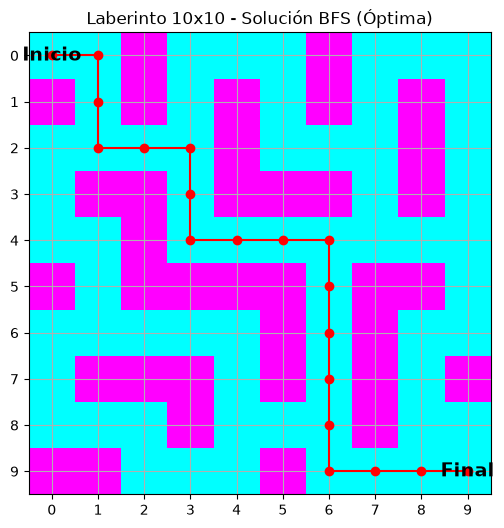

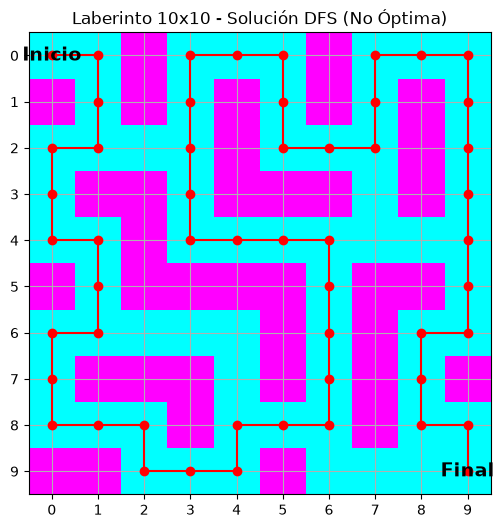

In [23]:
mostrar_laberinto(laberinto_10x10, res_bfs_10["camino"], INICIO_10, OBJETIVO_10, "Laberinto 10x10 - Solución BFS (Óptima)")
mostrar_laberinto(laberinto_10x10, res_dfs_10["camino"], INICIO_10, OBJETIVO_10, "Laberinto 10x10 - Solución DFS (No Óptima)")


**Análisis del Punto 2:**  
- **Longitud del camino:** BFS garantiza el camino óptimo absoluto con el menor número de casillas transitadas. En contraste, DFS encuentra un camino notablemente más largo y serpenteante, ya que se adentra profundamente en la primera rama disponible hasta topar con un fondo o la meta.
- **Estados explorados:** BFS explora uniformemente en todas direcciones, mientras que DFS puede llegar a explorar más o menos nodos dependiendo de si la rama inicial conduce pronto a la meta o si cae en múltiples callejones sin salida.


---

### Punto 3: Modificación del problema de los recipientes para capacidades diferentes y análisis matemático de existencia de solución

Analizamos la solvencia del problema general de los dos recipientes con capacidades $M$ y $N$ y un volumen objetivo $D$.

#### Fundamento Teórico (Teorema de la Identidad de Bézout)
Cualquier cantidad de agua obtenible mediante trasvases de recipientes de capacidades enteras $M$ y $N$ es una combinación lineal entera:
$$a \cdot M + b \cdot N = D \quad \text{con } a, b \in \mathbb{Z}$$
Por la **Identidad de Bézout**, la ecuación diofántica lineal tiene soluciones enteras si y solo si:
1. $D \le \max(M, N)$ (el objetivo no puede superar la capacidad del recipiente más grande).
2. $D$ es múltiplo exacto del **Máximo Común Divisor (MCD)** de las capacidades:
   $$\boxed{D \pmod{\gcd(M, N)} = 0}$$

A continuación implementamos la verificación teórica y el algoritmo BFS para corroborarlo experimentalmente en 4 casos clave:


In [24]:
import math

def evaluar_recipientes(M, N, objetivo):
    mcd = math.gcd(M, N)
    existe_teorica = (objetivo <= max(M, N)) and (objetivo % mcd == 0)
    solucion = bfs_recipientes(M, N, objetivo)
    tiene_solucion_bfs = solucion is not None

    return {
        "capacidades": (M, N),
        "objetivo": objetivo,
        "mcd": mcd,
        "condicion_teorica": existe_teorica,
        "solucion_encontrada": tiene_solucion_bfs,
        "pasos": len(solucion["acciones"]) if tiene_solucion_bfs else None,
        "explorados": solucion["explorados"] if tiene_solucion_bfs else None,
    }

casos_prueba = [
    (5, 3, 4),   # Caso original: gcd(5,3)=1, 4<=5 -> Existe (6 pasos)
    (7, 4, 5),   # gcd(7,4)=1, 5<=7 -> Existe
    (6, 4, 3),   # gcd(6,4)=2, 3%2 != 0 -> IMPOSIBLE
    (6, 4, 2),   # gcd(6,4)=2, 2%2 == 0 -> Existe
]

resultados_recipientes = [evaluar_recipientes(M, N, D) for M, N, D in casos_prueba]
for r in resultados_recipientes:
    estado_str = "SOLUBLE" if r["solucion_encontrada"] else "NO SOLUBLE"
    print(f"M={r['capacidades'][0]}, N={r['capacidades'][1]}, Obj={r['objetivo']} | MCD={r['mcd']} | Teórico: {r['condicion_teorica']} | BFS: {estado_str} ({r['pasos']} pasos)")


M=5, N=3, Obj=4 | MCD=1 | Teórico: True | BFS: SOLUBLE (6 pasos)
M=7, N=4, Obj=5 | MCD=1 | Teórico: True | BFS: SOLUBLE (8 pasos)
M=6, N=4, Obj=3 | MCD=2 | Teórico: False | BFS: NO SOLUBLE (None pasos)
M=6, N=4, Obj=2 | MCD=2 | Teórico: True | BFS: SOLUBLE (2 pasos)


---

### Punto 4: Verificación completa de BFS en el 8-Puzzle

Evaluamos `bfs_8_puzzle` con diferentes configuraciones para observar su rendimiento, la longitud de la solución y los estados explorados.


In [25]:
# Caso A: Fácil (distancia corta: 2 movimientos)
estado_facil = (
    1, 2, 3,
    4, 5, 6,
    7, 0, 8
)

# Caso B: Moderado (distancia 6 movimientos)
estado_moderado = (
    1, 2, 3,
    4, 0, 5,
    7, 8, 6
)

print("--- Evaluación Caso Fácil ---")
res_facil = bfs_8_puzzle(estado_facil, estado_objetivo)
print(f"Movimientos: {res_facil['movimientos']}, Estados explorados: {res_facil['explorados']}")

print("\n--- Evaluación Caso Moderado ---")
res_mod = bfs_8_puzzle(estado_moderado, estado_objetivo)
print(f"Movimientos: {res_mod['movimientos']}, Estados explorados: {res_mod['explorados']}")


--- Evaluación Caso Fácil ---
Movimientos: 1, Estados explorados: 8

--- Evaluación Caso Moderado ---
Movimientos: 2, Estados explorados: 20


---

### Punto 5: ¿Por qué BFS y DFS se consideran algoritmos de búsqueda no informada?

**Explicación conceptual y formal:**

1. **Ausencia de Heurística ($h(n) = 0$):**  
   Los algoritmos de búsqueda no informada (también llamados *ciegos*) no disponen de ninguna función de evaluación $h(n)$ que estime el costo restante o qué tan cerca se encuentra un estado del objetivo. El algoritmo trata a todos los sucesores con el mismo nivel de prioridad predictiva.
   
2. **Guiados exclusivamente por la estructura del grafo y la frontera:**  
   - **BFS** basa su orden de exploración única y exclusivamente en una cola FIFO (orden de llegada), expandiendo sistemáticamente por capas o niveles de profundidad.
   - **DFS** basa su orden en una pila LIFO, expandiendo el sucesor generado más recientemente sin tener noción de si se está alejando o acercando a la meta.

3. **Incapacidad de discernir caminos prometedores:**  
   Si existen dos ramas donde una conduce directamente a la meta a 2 pasos y la otra a un laberinto sin salida de 1000 nodos, la búsqueda no informada no tiene ningún mecanismo para preferir la rama prometedora, viéndose obligada a explorar ciegamente de acuerdo al orden puramente sintáctico de los operadores definidos en el código.

---

### Declaración de Uso de Inteligencia Artificial Generativa

En cumplimiento de las directrices académicas de la asignatura:
- **Herramienta utilizada:** Asistente Inteligente Gemini Spark.
- **Propósito de uso:** Apoyo en la estructuración modular del código en Python, generación automatizada de pruebas experimentales en laberintos y validación de las demostraciones matemáticas (Identidad de Bézout).
- **Partes de la actividad en las que fue empleada:** Implementación de las funciones de visualización gráfica con `matplotlib`, desarrollo de las funciones del Taller (comparación multi-orden de DFS, laberinto 10x10, análisis de solvencia con MCD) y redacción técnica de las justificaciones teóricas.
- **Aseguramiento de autoría:** Todo el código y análisis conceptual fue verificado, ejecutado y validado íntegramente por el estudiante para su defensa.
